# ESC-50 Dataset Exploration

## Objectives

- Inspect the dataset metadata.
- Check the number of recordings, classes, and folds.
- Verify audio formats, sample rates, channels, and durations.
- Listen to examples from several classes.
- Plot a waveform and a spectrogram.

In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display

# Resolve project paths from the notebooks directory.
PROJECT_ROOT = Path("..").resolve()
DATASET_ROOT = PROJECT_ROOT / "data" / "ESC-50"
AUDIO_DIR = DATASET_ROOT / "audio"
METADATA_PATH = DATASET_ROOT / "meta" / "esc50.csv"

assert AUDIO_DIR.is_dir(), f"Audio directory not found: {AUDIO_DIR}"
assert METADATA_PATH.is_file(), f"Metadata file not found: {METADATA_PATH}"

print(f"Dataset root: {DATASET_ROOT}")

Dataset root: /Users/rxffstxr/University/machine-learning/sound-recognition/data/ESC-50


In [2]:
metadata = pd.read_csv(METADATA_PATH)

print(f"Shape: {metadata.shape}")
display(metadata.head())

Shape: (2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [3]:
print(f"Recordings: {len(metadata)}")
print(f"Classes: {metadata['category'].nunique()}")
print(f"Folds: {sorted(metadata['fold'].unique())}")
print(f"Duplicate filenames: {metadata['filename'].duplicated().sum()}")

missing_values = metadata.isna().sum()
display(missing_values.to_frame(name="missing_values"))

Recordings: 2000
Classes: 50
Folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Duplicate filenames: 0


,missing_values
filename,0
fold,0
target,0
category,0
esc10,0
src_file,0
take,0


Unique class sizes: [np.int64(40)]


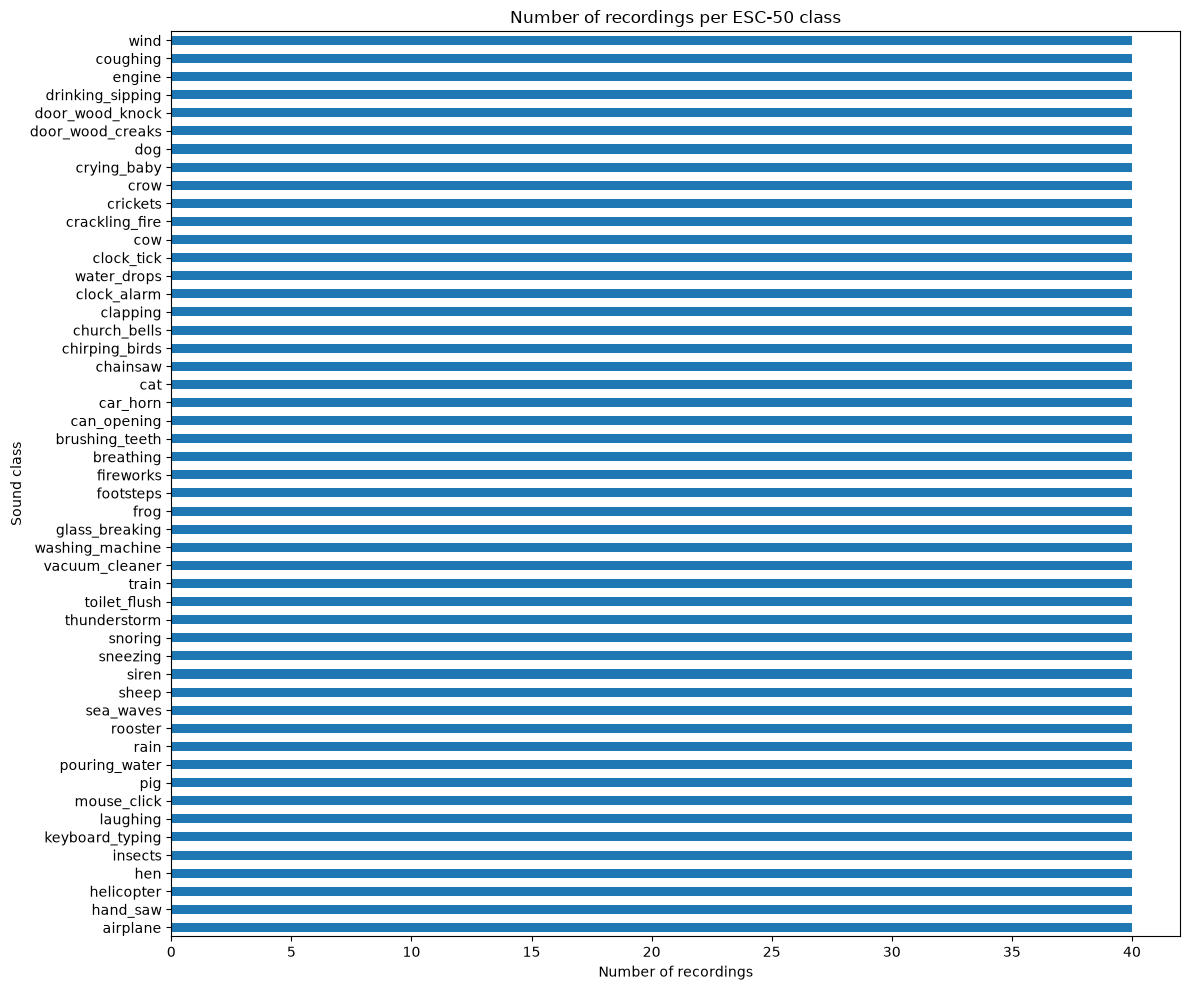

In [4]:
class_counts = metadata["category"].value_counts().sort_index()

print(f"Unique class sizes: {sorted(class_counts.unique())}")

fig, ax = plt.subplots(figsize=(12, 10))
class_counts.sort_values().plot.barh(ax=ax)

ax.set_title("Number of recordings per ESC-50 class")
ax.set_xlabel("Number of recordings")
ax.set_ylabel("Sound class")

plt.tight_layout()
plt.show()

,recordings
fold,
1,400
2,400
3,400
4,400
5,400


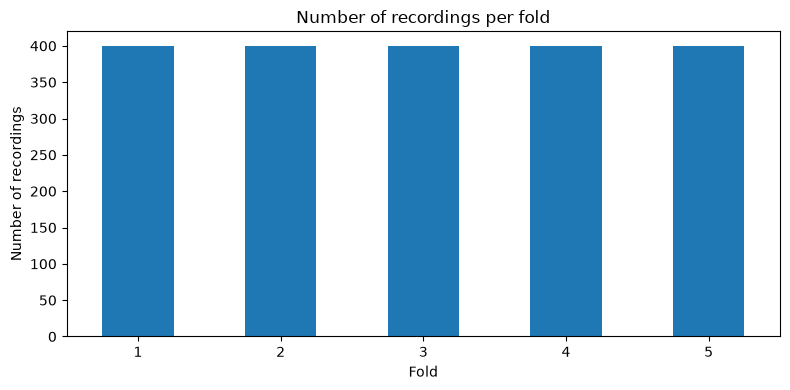

In [5]:
fold_counts = metadata["fold"].value_counts().sort_index()

display(fold_counts.to_frame(name="recordings"))

fig, ax = plt.subplots(figsize=(8, 4))
fold_counts.plot.bar(ax=ax)

ax.set_title("Number of recordings per fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Number of recordings")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [6]:
audio_properties = []

# Read audio headers without loading every signal into memory.
for audio_path in sorted(AUDIO_DIR.glob("*.wav")):
    info = sf.info(audio_path)
    audio_properties.append(
        {
            "filename": audio_path.name,
            "format": info.format,
            "subtype": info.subtype,
            "sample_rate": info.samplerate,
            "channels": info.channels,
            "duration": info.frames / info.samplerate,
        }
    )

audio_info = pd.DataFrame(audio_properties)

print(f"Audio files: {len(audio_info)}")
print(f"Formats: {sorted(audio_info['format'].unique())}")
print(f"Subtypes: {sorted(audio_info['subtype'].unique())}")
print(f"Sample rates: {sorted(audio_info['sample_rate'].unique())}")
print(f"Channel counts: {sorted(audio_info['channels'].unique())}")
print(f"Durations: {sorted(audio_info['duration'].unique())}")

Audio files: 2000
Formats: ['WAV']
Subtypes: ['PCM_16']
Sample rates: [np.int64(44100)]
Channel counts: [np.int64(1)]
Durations: [np.float64(5.0)]


In [7]:
example_categories = [
    "dog",
    "rain",
    "sea_waves",
    "siren",
    "keyboard_typing",
]

examples = (
    metadata[metadata["category"].isin(example_categories)]
    .sort_values(["category", "filename"])
    .groupby("category", as_index=False)
    .first()
)

display(examples[["category", "filename", "fold"]])

for row in examples.itertuples():
    audio_path = AUDIO_DIR / row.filename
    print(f"{row.category}: {row.filename}")
    display(Audio(filename=str(audio_path)))

,category,filename,fold
0,dog,1-100032-A-0.wav,1
1,keyboard_typing,1-137-A-32.wav,1
2,rain,1-17367-A-10.wav,1
3,sea_waves,1-28135-A-11.wav,1
4,siren,1-31482-A-42.wav,1


dog: 1-100032-A-0.wav


keyboard_typing: 1-137-A-32.wav


rain: 1-17367-A-10.wav


sea_waves: 1-28135-A-11.wav


siren: 1-31482-A-42.wav


Class: rain
Filename: 1-17367-A-10.wav
Samples: 220500
Sample rate: 44100
Duration: 5.00 seconds


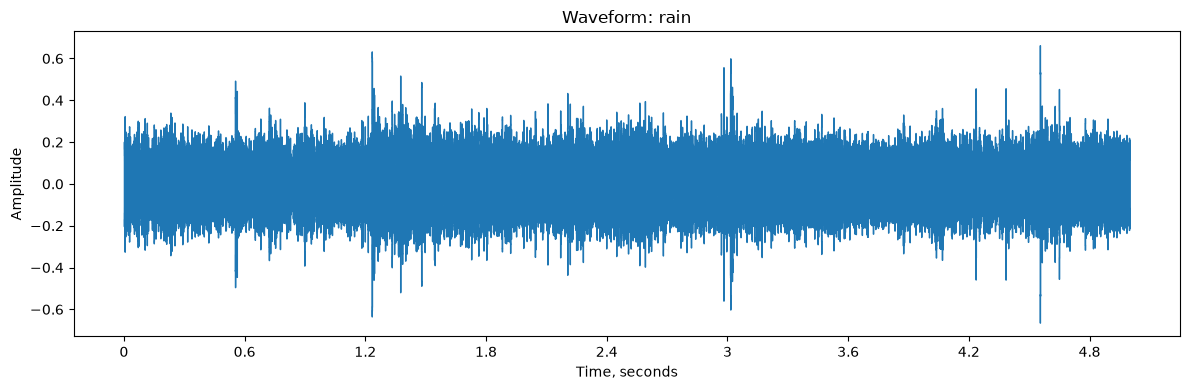

In [8]:
example = examples.loc[examples["category"] == "rain"].iloc[0]
example_path = AUDIO_DIR / example["filename"]

signal, sample_rate = librosa.load(example_path, sr=None, mono=True)

print(f"Class: {example['category']}")
print(f"Filename: {example['filename']}")
print(f"Samples: {len(signal)}")
print(f"Sample rate: {sample_rate}")
print(f"Duration: {len(signal) / sample_rate:.2f} seconds")

fig, ax = plt.subplots(figsize=(12, 4))
librosa.display.waveshow(signal, sr=sample_rate, ax=ax)

ax.set_title(f"Waveform: {example['category']}")
ax.set_xlabel("Time, seconds")
ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

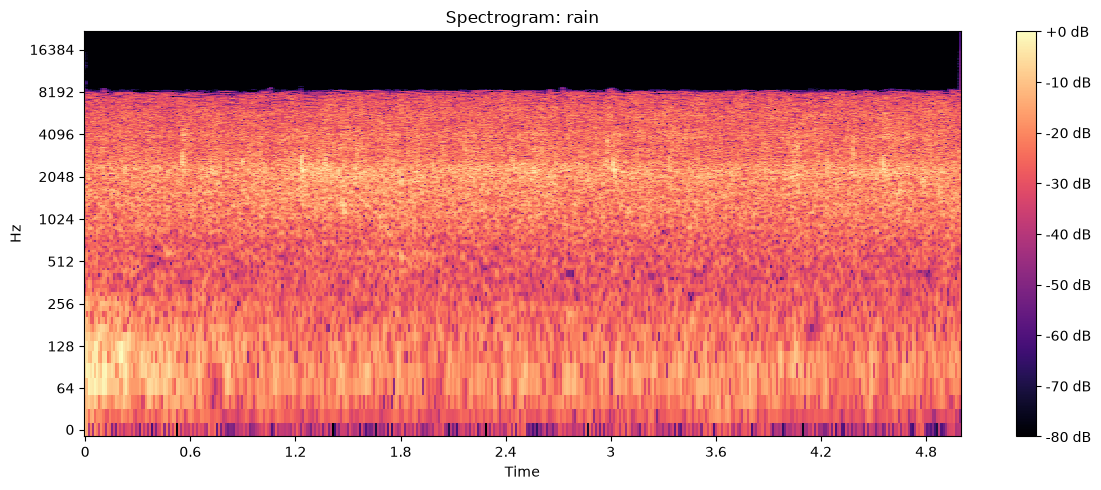

In [9]:
stft = librosa.stft(signal)
magnitude = np.abs(stft)
spectrogram_db = librosa.amplitude_to_db(magnitude, ref=np.max)

fig, ax = plt.subplots(figsize=(12, 5))

image = librosa.display.specshow(
    spectrogram_db,
    sr=sample_rate,
    x_axis="time",
    y_axis="log",
    ax=ax,
)

ax.set_title(f"Spectrogram: {example['category']}")
fig.colorbar(image, ax=ax, format="%+2.0f dB")

plt.tight_layout()
plt.show()

## Initial Findings

- ESC-50 contains 2,000 recordings divided into 50 classes.
- Every class contains 40 recordings.
- The dataset is divided into five predefined folds with 400 recordings each.
- All recordings use the WAV format with 16-bit PCM encoding.
- All recordings are mono, sampled at 44.1 kHz, and five seconds long.
- The predefined folds should be preserved during model evaluation.
- The full ESC-50 dataset is distributed under the CC BY-NC license.